# Ordinary Differential Equations: Initial Value Problems
Example problems to be solved:

1. 1st-order ordinary differential equation (ODE):

$\frac{dy(x)}{dx} = y'(x) = f(x, y(x))$, with known $y(a)=c$.

2. 2nd-order ODE:

$y''(x) = f(x,y,y')$, with known $y(a)=c$ and $y'(a)=d$.

## Forward Euler Method

$\frac{dy(x)}{dx}\sim \frac{y(x+h)-y(x)}{h} = f(x,y(x))$, which results in
$y(x+h) \sim y(x) + h\cdot f(x,y(x))$, or 

$y_{i+1} = y_i+h\cdot f(x_i,y_i)$, for $i=0,2,3, ..., n-2$.

This method produces a global error of $\sim O(h)$.

**Example.** Use the forward Euler method to solve the initial value problem $y'(x) = xy$, $y(0)=2$, between $0\le x \le 1$. As a benchmark, we know the exact solution is $y(x)=2e^{x^2/2}$.

In [1]:
# Import numpy and matplotlib for scientific calculation/visualization:
import numpy as np
import matplotlib.pyplot as plt

number of grid points n = 201
finite difference step size h = 0.005


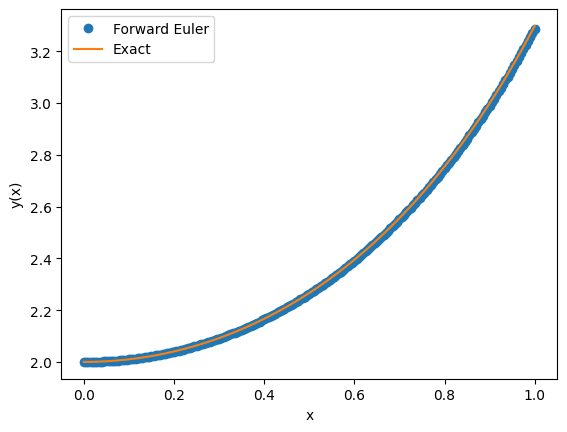

In [7]:
# discretize the x-axis
# set x-grid and spacing:
n = 201
a = 0
b = 1
h = (b-a)/(n-1)

print('number of grid points n =', n)
print('finite difference step size h =', h)

x = np.linspace(a,b,n)

# create y-grid:
y = np.zeros(n)

# initial condition:
y[0] = 2

for i in range(0, n-1):
    # Forward Euler:
    y[i+1] = y[i] + h * x[i]*y[i]
    
y_exact = 2*np.exp(x**2/2)

plt.plot(x, y, 'o', label='Forward Euler')
plt.plot(x, y_exact, label='Exact')

plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()

## Leap-Frog Method

Using the central difference $y'(x)\sim \frac{y(x+h)-y(x-h)}{2h}$, for the ODE $y'(x)=f(x,y)$, we have $y(x+h) \sim y(x-h) +2h\cdot f(x,y)$, or

$y_{i+1} = y_{i-1} + 2h\cdot f(x_i, y_i)$, where $i = 1, 2, .., n-2$.

Here, $y_0$ is known, and $y_1$ can be obtained with e.g. the forward Euler method.

The Leap-Frog method produces a global error of $\sim O(h^2)$, but it can easily be numerically **unstable**.

**Example.** Use the Leap-Frog and the forward Euler methods to solve the differential equation $\frac{dx(t)}{dt} = -x^3 + sin(t)$, with $x(t=0)=0$, in the range from $t=0$ to $t=10$.

**Note:** Here, $x$ is the function depending on the independent variable $t$.

number of grid points n = 101
finite difference step size h = 0.1


C:\Users\jifor\AppData\Local\Temp\ipykernel_3008\358536148.py:25: RuntimeWarning: overflow encountered in scalar power
  x[i+1] = x[i-1] + 2*h*(-x[i]**3 + np.sin(t[i]))


(-1.0, 1.0)

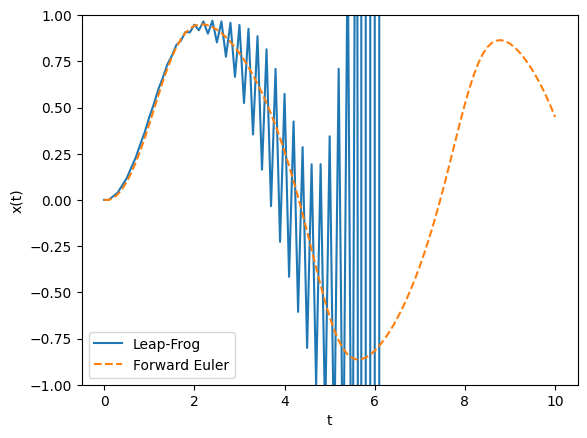

In [8]:
# set t-grid and spacing:
n = 101
a = 0
b = 10
h = (b-a)/(n-1)

print('number of grid points n =', n)
print('finite difference step size h =', h)

t = np.linspace(a,b,n)

# create x-grid:
x = np.zeros(n)

# initial condition: x0 = x(t_0 = 0)
# **Note**: "0" in LHS is not time = 0, but a Python list index value.
x[0] = 0

# For Leap-Frog, we need to known x_1 = x(t_1).
# Use the Forward Euler method to obtain x_1:
x[1] = x[0] + h*(-x[0]**3 + np.sin(t[0]))

for i in range(1, n-1):
    # Leap-Frog:
    x[i+1] = x[i-1] + 2*h*(-x[i]**3 + np.sin(t[i]))

# Use the Forward Euler method to compute all x(t):
x_FE = np.zeros(n)
for i in range(0, n-1):
    # Forward Euler:
    x_FE[i+1] = x_FE[i] + h * (-x_FE[i]**3 + np.sin(t[i]))
         
plt.plot(t, x,'-', label='Leap-Frog')
plt.plot(t, x_FE, '--', label='Forward Euler')

plt.xlabel('t')
plt.ylabel('x(t)')
plt.legend()

plt.ylim(-1,1)

## Explicit Runge-Kutta Methods

Recall, the problem we want to solve is $y'(x) = f(y(x), x)$, where $y(x_0)= y_0$ is known.

### Two-Step Runge-Kutta (or Midpoint Two-Step or Modified Euler)

$y_{i+1} = y_i + k_2\cdot h + O(h^3)$, where

$k_1 = f(y_i, x_i)$,

$k_2 = f(y_i + \frac1{2} k_1\cdot h, x_i + \frac1{2}h)$.

### Four-Step Runge-Kutta (RK4)
$y_{i+1}=y_i +\frac1{6}\cdot h \cdot (k_1+2k_2+2k_3+k_4) + O(h^5)$, where

$k_1 = f(y_i, x_i)$,

$k_2 = f(y_i+\frac1{2}k_1\cdot h, x_i+\frac1{2}h)$,

$k_3 = f(y_i + \frac1{2}k_2\cdot h, x_i+\frac1{2}h)$,

$k_4 = f(y_i + k_3\cdot h, x_i+h)$.

**Note:** Before careful about whether $h$ is included in the definitions of the $ks$.

**Example.** Use RK4 to solve the initial value problem $y'(x) = xy \equiv f(y, x)$, $y(0)=2$, between $0\le x \le 1$. As a benchmark, we know the exact solution is $y(x)=2e^{x^2/2}$.

number of grid points n = 11
finite difference step size h = 0.1


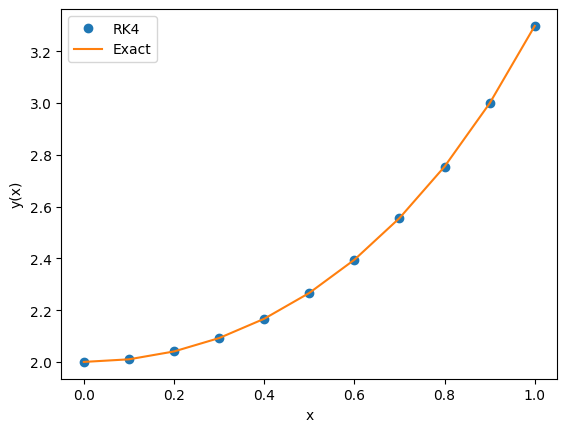

In [11]:
# set x-grid and spacing:
n = 11
a = 0
b = 1
h = (b-a)/(n-1)

print('number of grid points n =', n)
print('finite difference step size h =', h)

x = np.linspace(a,b,n)

# create y-grid:
y = np.zeros(n)
y[0] = 2

# define the ODE:
def f(y, x):
    return x*y

# define the RK4 method
for i in range(0, n-1):
    k1 = f(y[i], x[i])
    k2 = f(y[i]+k1*h/2, x[i]+h/2)
    k3 = f(y[i]+k2*h/2, x[i]+h/2)
    k4 = f(y[i]+k3*h, x[i]+h)
    
    y[i+1] = y[i] + h*(k1+2*k2+2*k3+k4)/6

y_exact = 2*np.exp(x**2/2)

plt.plot(x, y, 'o', label='RK4')
plt.plot(x, y_exact, label='Exact')

plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()

**Note:** As shown above, even with $h=0.1$, the RK4 agrees well with the exact solution.

## Simultaneous Ordinary Differential Equations
Consider $x=x(t)$ and $y=y(t)$, where $t$ is the independent variable.

We have $\frac{dx}{dt} = f_x(x,y,t)$, and $\frac{dy}{dt} = f_y(x,y,t)$.

Let $\mathbf{r} = (x(t), y(t))$, and $\mathbf{f}=(f_x,f_y)$. We then have

$\frac{d\mathbf{r}}{dt} = \mathbf{f}(\mathbf{r},t)$.

The above equation can be solved using the aforementioned methods. 

For example, using the Forward Euler:

$\mathbf{r}(t+h) = \mathbf{r}(t) + h\cdot\mathbf{f}(\mathbf{r},t)$.

For example, using RK4:

$\mathbf{r}(t+h) = \mathbf{r}(t) + \frac{h}{6}(\mathbf{k}_1+2\mathbf{k}_2+2\mathbf{k}_3+\mathbf{k}_4)$, where

$\mathbf{k_1} = \mathbf{f}(\mathbf{r},t)$,

$\mathbf{k_2} = \mathbf{f}(\mathbf{r}+\frac1{2}\mathbf{k}_1\cdot h,t+\frac{h}{2})$,

$\mathbf{k_3} = \mathbf{f}(\mathbf{r}+\frac1{2}\mathbf{k}_2\cdot h,t+\frac{h}{2})$,

$\mathbf{k_4} = \mathbf{f}(\mathbf{r}+\mathbf{k}_3\cdot h,t+h)$.

**Example.** $\frac{dx(t)}{dt} = xy-x$, $\frac{dy(t)}{dt}=y-xy+\sin^2 t$. For the initial conditions $x(0)=y(0)=1$, solve for $x$ and $y$ in the range $0\le t \le 10$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math as m

def f(r,t):
    x=r[0]
    y=r[1]
    fx = x*y-x
    fy = y-x*y+m.sin(t)**2
    return np.array([fx, fy])

#Note: r and f are both numpy arrays; each contains only 2 elements.

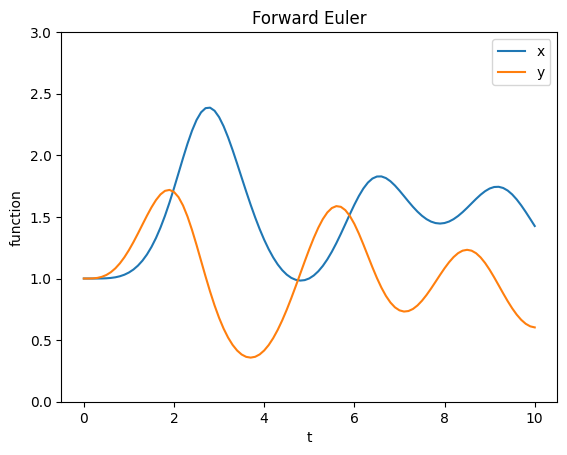

In [3]:
# Method 1: Forward Euler

# set t-grid:
a = 0
b = 10
n = 101
h = (b-a)/(n-1)

t = np.linspace(a,b,n)

# set x and y grids, and their initial values
x = np.zeros(n)
y = np.zeros(n)
x[0] = 1
y[0] = 1

# Note: r (at a given time) is an array of only 2 elements!
r = np.array([x[0],y[0]])

# Forward Euler:
for i in range(0,n-1):
    r = r + h*f(r, t[i])
    x[i+1] = r[0]
    y[i+1] = r[1]
    
plt.plot(t, x, label='x')
plt.plot(t, y, label='y')

plt.ylim(0,3)

plt.title('Forward Euler')
plt.xlabel('t')
plt.ylabel('function')
plt.legend()

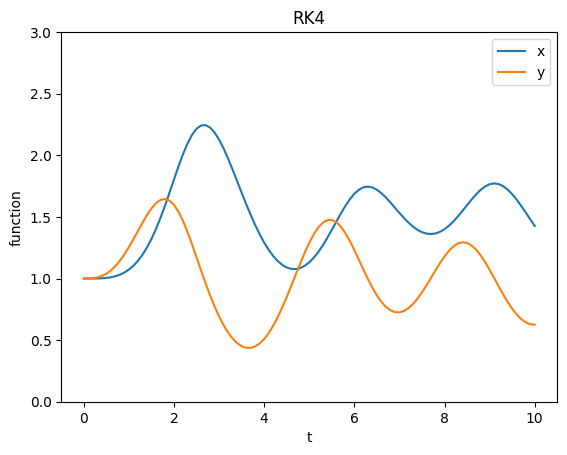

In [5]:
# Mehtod 2: RK4

# set t-grid:
a = 0
b = 10
n = 101
h = (b-a)/(n-1)

t = np.linspace(a,b,n)

# set x and y grids, and their initial values
x = np.zeros(n)
y = np.zeros(n)
x[0] = 1
y[0] = 1

r = np.array([x[0],y[0]])

# RK4:
for i in range(0,n-1):
    k1 = f(r,t[i])
    k2 = f(r+0.5*k1*h, t[i]+0.5*h)
    k3 = f(r+0.5*k2*h, t[i]+0.5*h)
    k4 = f(r+k3*h, t[i]+h)
    
    r = r + h*(k1+2*k2+2*k3+k4)/6

    x[i+1] = r[0]
    y[i+1] = r[1]

plt.plot(t, x, label='x')
plt.plot(t, y, label='y')

plt.ylim(0,3)

plt.title('RK4')
plt.xlabel('t')
plt.ylabel('function')
plt.legend()

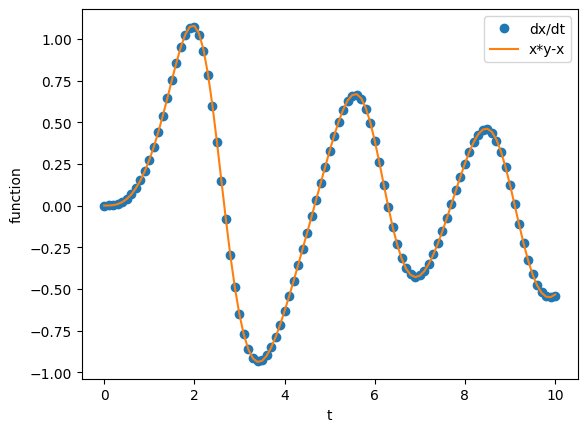

In [6]:
# Verify the numerical solutions:

# Remember to define the step size h, if you haven't yet.
# h = (b-a)/(n-1)

xprime = np.gradient(x, h)

plt.plot(t, xprime, 'o',label='dx/dt')
plt.plot(t, x*y-x, label='x*y-x')

plt.xlabel('t')
plt.ylabel('function')
plt.legend()

## Second-Order Ordinary Differential Equation

We want to solve $x''(t) = f(x(t), x'(t), t)$, a second-order ODE.

**Method (i):** Use e.g. central differences to approximate $x''$ and $x'$.

**Mehotd (ii):** Convert the 2nd-order ODE to two 1st-order ODEs:

Let $x'= dx/dt \equiv y$, we then have

$\frac{dx}{dt} = y \equiv f_x$,

$\frac{dy}{dt} = f(x, y, t) \equiv f_y$.

We can then use the abovementioned techniques for solving the two simultaneous 1st-order ODEs.

**Example: Nonlinear Pendulum.**
Equation of motion: $\frac{d^2\theta}{dt^2} = -\frac{g}{l}\sin\theta$, where $l$ is the pendulum arm length (in units of meter), and $g = 9.81$ meter/second$^2$. By defining a new variable $\omega(t) \equiv \frac{d\theta}{dt}$, we then have two simultaneous 1st-order ODEs:

$\frac{d\theta}{dt}=\omega \equiv f_\theta$,

$\frac{d\omega}{dt} = -\frac{g}{l}\sin\theta \equiv f_\omega$.

Solve $\theta(t)$ using RK4, and plot $\theta(t)$ for a few cycles of time. Consider respecitvely the following different initial conditions: with $\theta_0 = 5^\circ$, $\theta_0 = 15^\circ$, $\theta_0 = 30^\circ$, $\theta_0 = 179^\circ$. The pendulum is released from rest (i.e. $\theta'(0) = 0$).

In [7]:
import numpy as np
import math as m
import matplotlib.pyplot as plt

g = 9.81
l = 0.1 # in units of meter

def f(r,t):
    theta=r[0]
    omega=r[1]
    f_theta = omega
    f_omega = -(g/l)*m.sin(theta)
    return np.array([f_theta, f_omega])

number of grid points n = 201
finite difference step size h = 0.015859349623048535


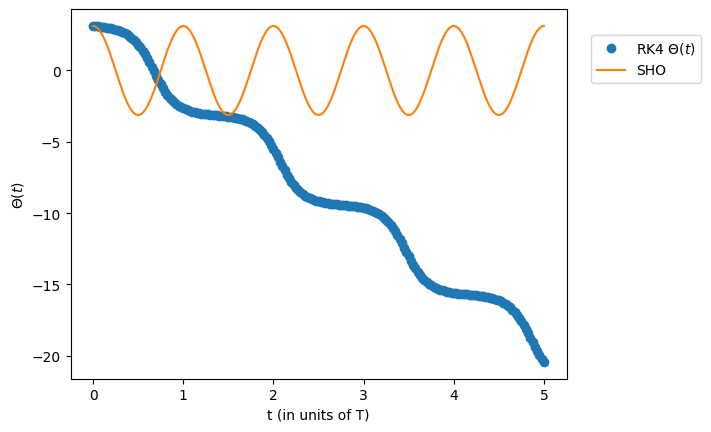

In [15]:
# set t-grid:
omega_0 = np.sqrt(g/l)
T = 2*np.pi/omega_0
# T is the period of a Simple Harmonic Oscillator approximation.

a = 0
b = 5*T 
n = 201
h = (b-a)/(n-1)

print('number of grid points n =', n)
print('finite difference step size h =', h)

t = np.linspace(a,b,n)

# set theta and omega grids, and their initial values
theta = np.zeros(n)
omega = np.zeros(n)

# Convert between degree and radian:
theta[0] = 179*np.pi/180 #1 degree = pi/180 rad
omega[0] = -1 #released from rest.

r = np.array([theta[0],omega[0]])

# RK4:
for i in range(0,n-1):
    k1 = f(r,t[i])
    k2 = f(r+0.5*k1*h, t[i]+0.5*h)
    k3 = f(r+0.5*k2*h, t[i]+0.5*h)
    k4 = f(r+k3*h, t[i]+h)
    
    r = r + h*(k1+2*k2+2*k3+k4)/6

    theta[i+1] = r[0]
    omega[i+1] = r[1]

#Solution for a Simple Harmonic Oscillator approximation:
sho = theta[0]*np.cos(omega_0*t)

plt.plot(t/T, theta, 'o', label=r"RK4 $\Theta (t)$")
plt.plot(t/T, sho, label='SHO')

plt.xlabel('t (in units of T)')
plt.ylabel(r'$\Theta(t)$')
plt.legend(loc=(1.05,0.8))